# DiCo-NLI UR2PhD Starter Assignment

**SemEval-2027 Task 2: Directional-Consistent Fine-Grained Natural Language Inference**

**Name:** Camila Peri  
**Mentor:** Sina Zamani Keshteli  
**University:** University of Alberta

## Table of Contents

1. **Part 0 — Setup**
   - Majority-Class Baseline

2. **Part 1 — Data Exploration**
   - Label Distributions
   - Examples per Label
   - Reversed Pair Structure

3. **Part 2 — System A: Fine-Tuned DistilBERT**
   - Model and Data Preparation
   - Fine-Tuning — Seed 42
   - Seed 42 Development Predictions
   - Fine-Tuning — Seed 123
   - Seed 123 Development Predictions
   - Multi-Seed Results

4. **Part 3 — System B: Prompted Qwen2.5-1.5B**
   - Model and Prompting Setup
   - Zero-Shot Prompting
   - Six-Shot Prompting
   - Overall Development-Set Results

5. **Part 4 — Analysis**
   - Confusion Matrices
   - Qualitative Error Analysis
   - SoftCons Failure Analysis
   - Next Step

# Part 0 — Setup

Set up the Google Colab environment, verify GPU availability, and clone the official DiCo-NLI repository.

In [58]:
# Check GPU availability
!nvidia-smi

# Clone the official DiCo-NLI repository
!git clone https://github.com/ilopezgazpio/SemEval-2027-Task-2-DiCo-NLI.git

# Move into the repository
%cd /content/SemEval-2027-Task-2-DiCo-NLI

Wed Oct  7 21:46:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             45W /   70W |    4841MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Majority-Class Baseline

As an initial check, I created a baseline that predicts the majority class (`NEGATIVE_OTHER`) for every development example and evaluated it using the official DiCo-NLI scorer.

In [59]:
import os
import pandas as pd

# Create output directory
os.makedirs("results", exist_ok=True)

# Load development reference data
dev_ref = pd.read_csv(
    "final_data/dev/dico_nli_dev_track1_reference.csv"
)

# Predict the majority class for every example
dev_preds = pd.DataFrame({
    "instance_id": dev_ref["instance_id"],
    "label": "NEGATIVE_OTHER"
})

# Save predictions
dev_preds.to_csv("results/majority_dev.csv", index=False)

# Evaluate with the official scorer
!python3 -m evaluation_functions \
    --gold final_data/dev/dico_nli_dev_track1_reference.csv \
    --predictions results/majority_dev.csv \
    --output-dir results/majority_scores

{
  "classification": {
    "accuracy": 0.1606060606060606,
    "confusion_matrix": {
      "BACKWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 0,
        "EQUIVALENCE": 0,
        "FORWARD_ENTAILMENT": 0,
        "NEGATIVE_OTHER": 190
      },
      "EQUIVALENCE": {
        "BACKWARD_ENTAILMENT": 0,
        "EQUIVALENCE": 0,
        "FORWARD_ENTAILMENT": 0,
        "NEGATIVE_OTHER": 174
      },
      "FORWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 0,
        "EQUIVALENCE": 0,
        "FORWARD_ENTAILMENT": 0,
        "NEGATIVE_OTHER": 190
      },
      "NEGATIVE_OTHER": {
        "BACKWARD_ENTAILMENT": 0,
        "EQUIVALENCE": 0,
        "FORWARD_ENTAILMENT": 0,
        "NEGATIVE_OTHER": 106
      }
    },
    "macro_f1": 0.06919060052219321,
    "per_label": {
      "BACKWARD_ENTAILMENT": {
        "f1": 0.0,
        "false_negative": 190,
        "false_positive": 0,
        "label": "BACKWARD_ENTAILMENT",
        "precision": 0.0,
        "predicted": 0,
        "recal

# Part 1 — Data Exploration

Explore the Track 1 training and development data by examining label distributions, examples from each class, and the structure of reversed pairs.

In [60]:
# Load training and development data
train_df = pd.read_csv(
    "final_data/train/dico_nli_train_track1_participant_labeled.csv"
)
dev_df = pd.read_csv(
    "final_data/dev/dico_nli_dev_track1_reference.csv"
)

# Label distributions
print("=== TRAIN LABEL DISTRIBUTION ===")
print(train_df["label"].value_counts())

print("\n=== DEV LABEL DISTRIBUTION ===")
print(dev_df["label"].value_counts())

# Three examples from each label
print("\n=== THREE EXAMPLES PER LABEL ===")

for label in train_df["label"].unique():
    print(f"\n--- {label} ---")
    samples = train_df[train_df["label"] == label].head(3)

    for _, row in samples.iterrows():
        print(f"Text 1: {row['text1']}")
        print(f"Text 2: {row['text2']}\n")

# Inspect reversed-pair structure
print("=== REVERSED PAIR SAMPLE ===")
print(
    dev_df[
        ["instance_id", "reverse_pair_id", "text1", "text2"]
    ].head(4)
)

=== TRAIN LABEL DISTRIBUTION ===
label
FORWARD_ENTAILMENT     881
BACKWARD_ENTAILMENT    881
EQUIVALENCE            802
NEGATIVE_OTHER         478
Name: count, dtype: int64

=== DEV LABEL DISTRIBUTION ===
label
FORWARD_ENTAILMENT     190
BACKWARD_ENTAILMENT    190
EQUIVALENCE            174
NEGATIVE_OTHER         106
Name: count, dtype: int64

=== THREE EXAMPLES PER LABEL ===

--- FORWARD_ENTAILMENT ---
Text 1: Conservative opposition
Text 2: Conservatives

Text 1: Japanese PM Shinzo Abe
Text 2: Abe

Text 1: ballistic missiles
Text 2: missiles


--- BACKWARD_ENTAILMENT ---
Text 1: Conservatives
Text 2: Conservative opposition

Text 1: Abe
Text 2: Japanese PM Shinzo Abe

Text 1: missiles
Text 2: ballistic missiles


--- EQUIVALENCE ---
Text 1: to Philippines
Text 2: for the Philippine nation

Text 1: for the Philippine nation
Text 2: to Philippines

Text 1: to repeal
Text 2: revokes


--- NEGATIVE_OTHER ---
Text 1: off Mexico
Text 2: on Mexico

Text 1: abortion bill
Text 2: against abor

## Examples per Label with Justifications

### 1. FORWARD_ENTAILMENT (`Text1` -> `Text2`)
> **Definition:** `Text1` is **Specific** and `Text2` is **General**. Truth flows forward from `Text1` to `Text2`.

1. **`Text1`:** "Pope Francis" | **`Text2`:** "pope"
   - **Arrow:** `"Pope Francis"` $\rightarrow$ `"pope"`
   - *Reason:* "Pope Francis" specifies the exact historical individual, which logically guarantees the general title "pope," but mentioning a general pope does not guarantee Pope Francis.
2. **`Text1`:** "Security video" | **`Text2`:** "Video"
   - **Arrow:** `"Security video"` $\rightarrow$ `"Video"`
   - *Reason:* A security video is a specific kind of recording, so having a security video guarantees having a video, but a general video is not necessarily a security video.
3. **`Text1`:** "Nine children" | **`Text2`:** "Five children"
   - **Arrow:** `"Nine children"` $\rightarrow$ `"Five children"`
   - *Reason:* The presence of nine children logically guarantees that there are at least five children, whereas having five children does not guarantee nine.

---

### 2. BACKWARD_ENTAILMENT (`Text1` <- `Text2`)
> **Definition:** `Text1` is **General** and `Text2` is **Specific**. Truth flows backward from `Text2` to `Text1`.

1. **`Text1`:** "One dead" | **`Text2`:** "Six killed"
   - **Arrow:** `"One dead"` $\leftarrow$ `"Six killed"`
   - *Reason:* Knowing "One dead" (`Text1`) does not guarantee six people died, but knowing `Text2` ("Six killed") logically guarantees that at least "One dead" (`Text1`) is true.
2. **`Text1`:** "World powers and Iran" | **`Text2`:** "Iran nuclear experts and also world powers"
   - **Arrow:** `"World powers and Iran"` $\leftarrow$ `"Iran nuclear experts and also world powers"`
   - *Reason:* Referring broadly to "Iran" (`Text1`) does not guarantee nuclear experts, but specifying `Text2` ("Iran nuclear experts...") guarantees `Text1` ("Iran").
3. **`Text1`:** "anti-protest law" | **`Text2`:** "anti-protest laws"
   - **Arrow:** `"anti-protest law"` $\leftarrow$ `"anti-protest laws"`
   - *Reason:* A single anti-protest law (`Text1`) does not guarantee multiple laws exist, but `Text2` ("laws", plural) guarantees the existence of an anti-protest law (`Text1`).

---

### 3. EQUIVALENCE (`Text1` <-> `Text2`)
> **Definition:** Both phrases express the exact same meaning in context, so truth flows in both directions.

1. **`Text1`:** "In Bhutto Death" | **`Text2`:** "over Bhutto murder"
   - **Arrow:** `"In Bhutto Death"` $\leftrightarrow$ `"over Bhutto murder"`
   - *Reason:* Both phrases refer to the exact same central event surrounding the death/killing of Benazir Bhutto.
2. **`Text1`:** "of bribing" | **`Text2`:** "to pay off"
   - **Arrow:** `"of bribing"` $\leftrightarrow$ `"to pay off"`
   - *Reason:* "Bribing" (formal legal term) and "paying off" (casual term) are exact synonyms describing the action of corruptly giving money to influence someone.
3. **`Text1`:** "Microsoft's productivity-software suite" | **`Text2`:** "Microsoft Office"
   - **Arrow:** `"Microsoft's productivity-software suite"` $\leftrightarrow$ `"Microsoft Office"`
   - *Reason:* "Microsoft Office" is the official product name for Microsoft's productivity-software suite, making the terms completely interchangeable.

---

### 4. NEGATIVE_OTHER (`Text1` != `Text2`)
> **Definition:** Neither phrase guarantees the other due to mutually exclusive meanings, opposite stances, or unrelated concepts.

1. **`Text1`:** "Syria opposition unity" | **`Text2`:** "Syria divided opposition"
   - **Arrow:** `"Syria opposition unity"` $\neq$ `"Syria divided opposition"`
   - *Reason:* "Unity" and "divided" express opposite, mutually exclusive organizational states, so neither statement entails the other.
2. **`Text1`:** "out of the water" | **`Text2`:** "through the water"
   - **Arrow:** `"out of the water"` $\neq$ `"through the water"`
   - *Reason:* Moving "out of" water and moving "through" water are distinct spatial movements that do not imply one another.
3. **`Text1`:** "to Farrow" | **`Text2`:** "against Farrow"
   - **Arrow:** `"to Farrow"` $\neq$ `"against Farrow"`
   - *Reason:* The prepositions "to" (direction/recipient) and "against" (opposition) change the stance completely, breaking any logical entailment.

### Reversed Pair Structure

Each example is linked to a reversed counterpart through `reverse_pair_id`. The example below shows how `text1` and `text2` are swapped in the reversed pair and how the corresponding label changes.

In [61]:
# Select an original example
original_row = dev_df[
    dev_df["instance_id"].str.endswith("__original")
].iloc[0]

# Find its reversed counterpart
flipped_row = dev_df[
    dev_df["instance_id"] == original_row["reverse_pair_id"]
].iloc[0]

# Display both pairs
cols = ["text1", "text2", "label", "instance_id", "reverse_pair_id"]

comparison_df = pd.DataFrame([
    original_row[cols],
    flipped_row[cols]
])

comparison_df.index = ["Original Pair", "Reversed Pair"]

display(comparison_df)

,text1,text2,label,instance_id,reverse_pair_id
Original Pair,'s shrine visit,'s war shrine visit,BACKWARD_ENTAILMENT,dico_phrasis_0000002__en-en__original,dico_phrasis_0000002__en-en__flipped
Reversed Pair,'s war shrine visit,'s shrine visit,FORWARD_ENTAILMENT,dico_phrasis_0000002__en-en__flipped,dico_phrasis_0000002__en-en__original


### Interpretation of Reversed Pair Linkage

Each phrase pair shares a base identifier, while the `__original` and `__flipped` suffixes distinguish the two orderings. The `reverse_pair_id` column directly links each row to its reversed counterpart.

When the pair is reversed, `text1` and `text2` swap positions. For directional relationships, this also reverses the label: `FORWARD_ENTAILMENT` becomes `BACKWARD_ENTAILMENT`, and vice versa. Symmetric relationships, such as `EQUIVALENCE` and `NEGATIVE_OTHER`, remain unchanged under reversal.

# Part 2 — System A: Fine-Tuned Encoder

Fine-tune and evaluate `distilbert-base-uncased` on the DiCo-NLI Track 1 training data using two random seeds (42 and 123). Development-set predictions are evaluated using the official Weighted F1, SoftCons, and HardCons metrics.

## 2.1 Model and Data Preparation

I initially attempted to fine-tune the recommended `microsoft/deberta-v3-base` checkpoint as a four-class sequence-pair classifier. However, training repeatedly became unstable with FP16 mixed precision in the available Google Colab T4 environment, producing `NaN` losses and preventing a reliable training run. Using FP32 would have required more GPU memory and training time than was available.

Following the assignment guidelines, I therefore switched to `distilbert-base-uncased` for the final System A experiments. DistilBERT was trained for four epochs with a learning rate of `3e-5`, batch size of `16`, maximum sequence length of `128`, and FP16 precision. Two random seeds, `42` and `123`, were used for the final experiments.

In [62]:
# Initial System A approach
# The recommended DeBERTa-v3-base checkpoint was attempted first.
INITIAL_MODEL_NAME = "microsoft/deberta-v3-base"

# The attempted FP16 run became unstable and produced NaN losses
# in the available Google Colab T4 environment.
print("Initial attempted model:", INITIAL_MODEL_NAME)
print("Result: FP16 training was unstable, so DistilBERT was used as the fallback.")

Initial attempted model: microsoft/deberta-v3-base
Result: FP16 training was unstable, so DistilBERT was used as the fallback.


In [38]:
# Install required libraries
!pip install -q evaluate scikit-learn

# Import libraries
import numpy as np
import torch
import evaluate

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

# Final model used for System A
MODEL_NAME = "distilbert-base-uncased"

# Map DiCo-NLI labels to numeric IDs
label2id = {
    "FORWARD_ENTAILMENT": 0,
    "BACKWARD_ENTAILMENT": 1,
    "EQUIVALENCE": 2,
    "NEGATIVE_OTHER": 3
}

# Convert numeric IDs back to label names
id2label = {v: k for k, v in label2id.items()}

# Preserve the original DataFrames
train_encoded = train_df.copy()
dev_encoded = dev_df.copy()

# Convert string labels to numeric IDs
train_encoded["label"] = train_encoded["label"].map(label2id)
dev_encoded["label"] = dev_encoded["label"].map(label2id)

# Convert DataFrames to Hugging Face datasets
train_dataset = Dataset.from_pandas(
    train_encoded[["text1", "text2", "label"]]
)

dev_dataset = Dataset.from_pandas(
    dev_encoded[["text1", "text2", "label"]]
)

# Load the DistilBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize each text pair
def preprocess_function(examples):
    return tokenizer(
        examples["text1"],
        examples["text2"],
        truncation=True,
        max_length=128
    )

# Tokenize training data
tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["text1", "text2"]
)

# Tokenize development data
tokenized_dev = dev_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["text1", "text2"]
)

# Dynamically pad examples within each batch
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

Map:   0%|          | 0/3042 [00:00<?, ? examples/s]

Map:   0%|          | 0/660 [00:00<?, ? examples/s]

## 2.2 Fine-Tuning — Seed 42

Fine-tune DistilBERT using random seed `42` and evaluate the model on the development set during training.

In [39]:
# Load evaluation metrics used during training
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

# Compute accuracy and macro F1 during evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    macro_f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="macro"
    )["f1"]

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

# Initialize DistilBERT for four-class classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

# Training configuration for Seed 42
training_args = TrainingArguments(
    output_dir="./distilbert_dico_nli_results",
    seed=42,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    fp16=True,
    logging_steps=20,
    report_to="none"
)

# Create the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Fine-tune the model
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.164018,1.217020,0.422727,0.358765
2,0.870725,1.227248,0.521212,0.502636
3,0.596186,1.250106,0.559091,0.536188
4,0.563013,1.276189,0.589394,0.563150


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=764, training_loss=0.8533044635313344, metrics={'train_runtime': 117.9863, 'train_samples_per_second': 103.131, 'train_steps_per_second': 6.475, 'total_flos': 50202795011712.0, 'train_loss': 0.8533044635313344, 'epoch': 4.0})

## 2.3 Seed 42 — Development Predictions

Generate predictions from the trained Seed 42 model and save them in the official `(instance_id, label)` format for evaluation with the DiCo-NLI scorer.

In [40]:
# Generate predictions for the development set
raw_preds_seed42 = trainer.predict(tokenized_dev)
pred_ids_seed42 = np.argmax(
    raw_preds_seed42.predictions,
    axis=1
)

# Convert numeric prediction IDs back to DiCo-NLI labels
pred_labels_seed42 = [
    id2label[i] for i in pred_ids_seed42
]

# Format predictions for the official scorer
preds_df_seed42 = pd.DataFrame({
    "instance_id": dev_df["instance_id"],
    "label": pred_labels_seed42
})

# Create the results directory if needed
os.makedirs("results", exist_ok=True)

# Save Seed 42 development predictions
preds_df_seed42.to_csv(
    "results/system_a_seed42.csv",
    index=False
)

print("Saved predictions to results/system_a_seed42.csv")

Saved predictions to results/system_a_seed42.csv


In [41]:
# Evaluate Seed 42 predictions with the official DiCo-NLI scorer
!python3 -m evaluation_functions \
    --gold final_data/dev/dico_nli_dev_track1_reference.csv \
    --predictions results/system_a_seed42.csv \
    --output-dir results/system_a_seed42_scores

{
  "classification": {
    "accuracy": 0.5893939393939394,
    "confusion_matrix": {
      "BACKWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 138,
        "EQUIVALENCE": 24,
        "FORWARD_ENTAILMENT": 13,
        "NEGATIVE_OTHER": 15
      },
      "EQUIVALENCE": {
        "BACKWARD_ENTAILMENT": 19,
        "EQUIVALENCE": 101,
        "FORWARD_ENTAILMENT": 27,
        "NEGATIVE_OTHER": 27
      },
      "FORWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 34,
        "EQUIVALENCE": 22,
        "FORWARD_ENTAILMENT": 112,
        "NEGATIVE_OTHER": 22
      },
      "NEGATIVE_OTHER": {
        "BACKWARD_ENTAILMENT": 22,
        "EQUIVALENCE": 12,
        "FORWARD_ENTAILMENT": 34,
        "NEGATIVE_OTHER": 38
      }
    },
    "macro_f1": 0.5631498566038717,
    "per_label": {
      "BACKWARD_ENTAILMENT": {
        "f1": 0.684863523573201,
        "false_negative": 52,
        "false_positive": 75,
        "label": "BACKWARD_ENTAILMENT",
        "precision": 0.647887323943662,


## 2.4 Fine-Tuning — Seed 123

Re-initialize DistilBERT and fine-tune the model using random seed `123` with the same hyperparameters used for Seed 42.

In [42]:
# Re-initialize DistilBERT for the second run
model_seed123 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

# Configure training with random seed 123
training_args_seed123 = TrainingArguments(
    output_dir="./distilbert_dico_nli_results_seed123",
    seed=123,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    fp16=True,
    logging_steps=20,
    report_to="none"
)

# Create the Trainer for Seed 123
trainer_seed123 = Trainer(
    model=model_seed123,
    args=training_args_seed123,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Fine-tune the model
trainer_seed123.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.133163,1.268914,0.437879,0.350427
2,0.868952,1.106607,0.568182,0.539811
3,0.647772,1.117871,0.606061,0.584375
4,0.568316,1.134459,0.615152,0.590748


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=764, training_loss=0.8626469592149345, metrics={'train_runtime': 133.301, 'train_samples_per_second': 91.282, 'train_steps_per_second': 5.731, 'total_flos': 50008226580480.0, 'train_loss': 0.8626469592149345, 'epoch': 4.0})

## 2.5 Seed 123 — Development Predictions

Generate predictions from the trained Seed 123 model and save them in the official `(instance_id, label)` format for evaluation with the DiCo-NLI scorer.

In [43]:
# Generate predictions for the development set
raw_preds_seed123 = trainer_seed123.predict(tokenized_dev)
pred_ids_seed123 = np.argmax(
    raw_preds_seed123.predictions,
    axis=1
)

# Convert numeric prediction IDs back to DiCo-NLI labels
pred_labels_seed123 = [
    id2label[i] for i in pred_ids_seed123
]

# Format predictions for the official scorer
preds_df_seed123 = pd.DataFrame({
    "instance_id": dev_df["instance_id"],
    "label": pred_labels_seed123
})

# Save Seed 123 development predictions
preds_df_seed123.to_csv(
    "results/system_a_seed123.csv",
    index=False
)

print("Saved predictions to results/system_a_seed123.csv")

Saved predictions to results/system_a_seed123.csv


In [44]:
# Evaluate Seed 123 predictions with the official DiCo-NLI scorer
!python3 -m evaluation_functions \
    --gold final_data/dev/dico_nli_dev_track1_reference.csv \
    --predictions results/system_a_seed123.csv \
    --output-dir results/system_a_seed123_scores

{
  "classification": {
    "accuracy": 0.6151515151515151,
    "confusion_matrix": {
      "BACKWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 140,
        "EQUIVALENCE": 27,
        "FORWARD_ENTAILMENT": 15,
        "NEGATIVE_OTHER": 8
      },
      "EQUIVALENCE": {
        "BACKWARD_ENTAILMENT": 22,
        "EQUIVALENCE": 102,
        "FORWARD_ENTAILMENT": 28,
        "NEGATIVE_OTHER": 22
      },
      "FORWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 28,
        "EQUIVALENCE": 18,
        "FORWARD_ENTAILMENT": 122,
        "NEGATIVE_OTHER": 22
      },
      "NEGATIVE_OTHER": {
        "BACKWARD_ENTAILMENT": 21,
        "EQUIVALENCE": 12,
        "FORWARD_ENTAILMENT": 31,
        "NEGATIVE_OTHER": 42
      }
    },
    "macro_f1": 0.5907478322584986,
    "per_label": {
      "BACKWARD_ENTAILMENT": {
        "f1": 0.6982543640897756,
        "false_negative": 50,
        "false_positive": 71,
        "label": "BACKWARD_ENTAILMENT",
        "precision": 0.6635071090047393,

## 2.6 Multi-Seed Results

The official development-set scores from Seeds `42` and `123` are summarized below. The mean and spread are calculated across the two runs for Weighted F1, SoftCons, and HardCons.

In [45]:
import json
import pandas as pd

# Load official scorer results for both System A seeds
score_paths = {
    42: "results/system_a_seed42_scores/scores.json",
    123: "results/system_a_seed123_scores/scores.json"
}

rows = []

for seed, path in score_paths.items():
    with open(path, "r") as f:
        scores = json.load(f)

    rows.append({
        "Seed": seed,
        "Weighted F1": scores["classification"]["weighted_f1"],
        "SoftCons": scores["consistency"]["soft_cons"],
        "HardCons": scores["consistency"]["hard_cons"]
    })

# Create results table directly from official scorer outputs
seed_results = pd.DataFrame(rows)

# Calculate mean and spread across the two seeds
metrics = ["Weighted F1", "SoftCons", "HardCons"]

mean_scores = seed_results[metrics].mean()

spread_scores = (
    seed_results[metrics].max()
    - seed_results[metrics].min()
) / 2

# Display individual seed results
display(seed_results)

# Display mean ± spread
print("\nMean ± Spread")

for metric in metrics:
    print(
        f"{metric}: "
        f"{mean_scores[metric]:.4f} ± "
        f"{spread_scores[metric]:.4f}"
    )

,Seed,Weighted F1,SoftCons,HardCons
0,42,0.587266,0.613718,0.523466
1,123,0.611949,0.642599,0.548736



Mean ± Spread
Weighted F1: 0.5996 ± 0.0123
SoftCons: 0.6282 ± 0.0144
HardCons: 0.5361 ± 0.0126


# Part 3 — System B: Prompted LLM

Evaluate `Qwen2.5-1.5B-Instruct` on the DiCo-NLI Track 1 development set without fine-tuning. Two prompting strategies are compared: zero-shot prompting and 6-shot prompting. Model outputs are converted to the four DiCo-NLI labels using a parser and evaluated with the official scorer.

## 3.1 Model and Prompting Setup

Load `Qwen2.5-1.5B-Instruct`, define the DiCo-NLI classification prompt and six few-shot demonstrations, and create a parser that converts model responses into valid labels.

In [46]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Qwen model used for System B
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

# Define the classification instructions
SYSTEM_PROMPT = """You are an expert logician and computational linguist.
Your task is to predict the Natural Language Inference (NLI) relationship between text1 and text2.

Select EXACTLY ONE of the following four labels:
1. EQUIVALENCE: text1 and text2 mean the same thing.
2. FORWARD_ENTAILMENT: text1 entails text2 (if text1 is true, text2 must be true).
3. BACKWARD_ENTAILMENT: text2 entails text1 (if text2 is true, text1 must be true).
4. NEGATIVE_OTHER: any other relationship (contradiction, unrelated, neutral, etc.).

Respond with ONLY the exact label name. Do not output any explanation or extra text."""

# Six demonstrations used for 6-shot prompting
FEW_SHOT_EXAMPLES = """
Here are some examples of correctly classified pairs:

Example 1:
text1: Every person is hungry.
text2: Someone is hungry.
Label: FORWARD_ENTAILMENT

Example 2:
text1: Someone is hungry.
text2: Every person is hungry.
Label: BACKWARD_ENTAILMENT

Example 3:
text1: The dog is sleeping on the mat.
text2: A canine is asleep on the rug.
Label: EQUIVALENCE

Example 4:
text1: The child is running quickly.
text2: The child is standing still.
Label: NEGATIVE_OTHER

Example 5:
text1: All cats are mammals.
text2: Some cats are mammals.
Label: FORWARD_ENTAILMENT

Example 6:
text1: The laptop is turned off.
text2: The computer is running a heavy simulation.
Label: NEGATIVE_OTHER
"""

# Valid DiCo-NLI labels
VALID_LABELS = [
    "EQUIVALENCE",
    "FORWARD_ENTAILMENT",
    "BACKWARD_ENTAILMENT",
    "NEGATIVE_OTHER"
]

# Convert generated text into a valid DiCo-NLI label
def parse_llm_output(output_text):
    clean_text = output_text.strip().upper()

    for label in VALID_LABELS:
        if label in clean_text:
            return label, True

    # Fallback for unparseable responses
    return "NEGATIVE_OTHER", False

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [47]:
# Run Qwen on the development set
def run_llm_evaluation(few_shot=False):
    predictions = []
    unparsed_count = 0

    for idx, row in dev_df.iterrows():

        # Add demonstrations only for the 6-shot condition
        if few_shot:
            user_prompt = (
                f"{FEW_SHOT_EXAMPLES}\n"
                f"Now classify this item:\n"
                f"text1: {row['text1']}\n"
                f"text2: {row['text2']}\n"
                f"Label:"
            )
        else:
            user_prompt = (
                f"text1: {row['text1']}\n"
                f"text2: {row['text2']}\n"
                f"Label:"
            )

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ]

        # Format the prompt using Qwen's chat template
        prompt_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        model_inputs = tokenizer(
            [prompt_text],
            return_tensors="pt"
        ).to(model.device)

        # Generate the model response
        with torch.no_grad():
            generated_ids = model.generate(
                **model_inputs,
                max_new_tokens=15,
                do_sample=False
            )

        # Remove the input tokens from the generated sequence
        generated_ids = [
            output_ids[len(input_ids):]
            for input_ids, output_ids
            in zip(model_inputs.input_ids, generated_ids)
        ]

        response = tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True
        )[0]

        # Parse the generated response
        parsed_label, is_valid = parse_llm_output(response)

        if not is_valid:
            unparsed_count += 1

        predictions.append(parsed_label)

    return predictions, unparsed_count

## 3.2 Zero-Shot Prompting

Evaluate Qwen on the development set without providing labeled demonstrations. Save the predictions in the official format, report the number of unparsed outputs, and evaluate them using the official DiCo-NLI scorer.

In [48]:
# Run zero-shot inference on the development set
zero_predictions, zero_unparsed = run_llm_evaluation(
    few_shot=False
)

# Save predictions in the official (instance_id, label) format
zero_df = pd.DataFrame({
    "instance_id": dev_df["instance_id"],
    "label": zero_predictions
})

zero_df.to_csv(
    "results/system_b_zeroshot.csv",
    index=False
)

# Report parser performance
print(f"Unparsed outputs: {zero_unparsed}/{len(dev_df)}")
print("Saved predictions to results/system_b_zeroshot.csv")

Unparsed outputs: 0/660
Saved predictions to results/system_b_zeroshot.csv


In [49]:
# Evaluate zero-shot predictions with the official DiCo-NLI scorer
!python3 -m evaluation_functions \
    --gold final_data/dev/dico_nli_dev_track1_reference.csv \
    --predictions results/system_b_zeroshot.csv \
    --output-dir results/system_b_zeroshot_scores

{
  "classification": {
    "accuracy": 0.2833333333333333,
    "confusion_matrix": {
      "BACKWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 4,
        "EQUIVALENCE": 5,
        "FORWARD_ENTAILMENT": 151,
        "NEGATIVE_OTHER": 30
      },
      "EQUIVALENCE": {
        "BACKWARD_ENTAILMENT": 3,
        "EQUIVALENCE": 11,
        "FORWARD_ENTAILMENT": 149,
        "NEGATIVE_OTHER": 11
      },
      "FORWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 1,
        "EQUIVALENCE": 19,
        "FORWARD_ENTAILMENT": 128,
        "NEGATIVE_OTHER": 42
      },
      "NEGATIVE_OTHER": {
        "BACKWARD_ENTAILMENT": 4,
        "EQUIVALENCE": 0,
        "FORWARD_ENTAILMENT": 58,
        "NEGATIVE_OTHER": 44
      }
    },
    "macro_f1": 0.22531193664408097,
    "per_label": {
      "BACKWARD_ENTAILMENT": {
        "f1": 0.0396039603960396,
        "false_negative": 186,
        "false_positive": 8,
        "label": "BACKWARD_ENTAILMENT",
        "precision": 0.3333333333333333,
   

## 3.3 Six-Shot Prompting

Evaluate Qwen on the development set using six labeled demonstrations. Save the predictions in the official format, report the number of unparsed outputs, and evaluate them using the official DiCo-NLI scorer.

In [50]:
# Run 6-shot inference on the development set
sixshot_predictions, sixshot_unparsed = run_llm_evaluation(
    few_shot=True
)

# Save predictions in the official (instance_id, label) format
sixshot_df = pd.DataFrame({
    "instance_id": dev_df["instance_id"],
    "label": sixshot_predictions
})

sixshot_df.to_csv(
    "results/system_b_6shot.csv",
    index=False
)

# Report parser performance
print(f"Unparsed outputs: {sixshot_unparsed}/{len(dev_df)}")
print("Saved predictions to results/system_b_6shot.csv")

Unparsed outputs: 0/660
Saved predictions to results/system_b_6shot.csv


In [51]:
# Evaluate 6-shot predictions with the official DiCo-NLI scorer
!python3 -m evaluation_functions \
    --gold final_data/dev/dico_nli_dev_track1_reference.csv \
    --predictions results/system_b_6shot.csv \
    --output-dir results/system_b_6shot_scores

{
  "classification": {
    "accuracy": 0.296969696969697,
    "confusion_matrix": {
      "BACKWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 0,
        "EQUIVALENCE": 89,
        "FORWARD_ENTAILMENT": 53,
        "NEGATIVE_OTHER": 48
      },
      "EQUIVALENCE": {
        "BACKWARD_ENTAILMENT": 0,
        "EQUIVALENCE": 90,
        "FORWARD_ENTAILMENT": 65,
        "NEGATIVE_OTHER": 19
      },
      "FORWARD_ENTAILMENT": {
        "BACKWARD_ENTAILMENT": 0,
        "EQUIVALENCE": 90,
        "FORWARD_ENTAILMENT": 50,
        "NEGATIVE_OTHER": 50
      },
      "NEGATIVE_OTHER": {
        "BACKWARD_ENTAILMENT": 0,
        "EQUIVALENCE": 28,
        "FORWARD_ENTAILMENT": 22,
        "NEGATIVE_OTHER": 56
      }
    },
    "macro_f1": 0.261689297897164,
    "per_label": {
      "BACKWARD_ENTAILMENT": {
        "f1": 0.0,
        "false_negative": 190,
        "false_positive": 0,
        "label": "BACKWARD_ENTAILMENT",
        "precision": 0.0,
        "predicted": 0,
        "reca

## 3.4 Overall Development-Set Results

The table below summarizes the official development-set results for both systems alongside the pilot DeBERTa-v3-base reference results.

In [52]:
import json
import pandas as pd

# Paths to official scorer results for all reported runs
result_paths = {
    "System A — DistilBERT (Seed 42)":
        "results/system_a_seed42_scores/scores.json",

    "System A — DistilBERT (Seed 123)":
        "results/system_a_seed123_scores/scores.json",

    "System B — Qwen (Zero-Shot)":
        "results/system_b_zeroshot_scores/scores.json",

    "System B — Qwen (6-Shot)":
        "results/system_b_6shot_scores/scores.json"
}

rows = []

# Pilot reference values from the task
rows.append({
    "System": "Pilot Reference (DeBERTa-v3-base)",
    "Weighted F1": "0.7500",
    "SoftCons": "0.8400",
    "HardCons": "0.7900"
})

# Read experimental results directly from official scorer outputs
for system, path in result_paths.items():
    with open(path, "r") as f:
        scores = json.load(f)

    rows.append({
        "System": system,
        "Weighted F1":
            f"{scores['classification']['weighted_f1']:.4f}",
        "SoftCons":
            f"{scores['consistency']['soft_cons']:.4f}",
        "HardCons":
            f"{scores['consistency']['hard_cons']:.4f}"
    })

# Add System A mean ± spread calculated in Section 2.6
mean_row = {
    "System": "System A — Mean ± Spread",

    "Weighted F1":
        f"{mean_scores['Weighted F1']:.4f} ± "
        f"{spread_scores['Weighted F1']:.4f}",

    "SoftCons":
        f"{mean_scores['SoftCons']:.4f} ± "
        f"{spread_scores['SoftCons']:.4f}",

    "HardCons":
        f"{mean_scores['HardCons']:.4f} ± "
        f"{spread_scores['HardCons']:.4f}"
}

# Put the mean row after the two System A seed results
rows.insert(3, mean_row)

# Create and display final results table
overall_results = pd.DataFrame(rows)

display(overall_results)

,System,Weighted F1,SoftCons,HardCons
0,Pilot Reference (DeBERTa-v3-base),0.7500,0.8400,0.7900
1,System A — DistilBERT (Seed 42),0.5873,0.6137,0.5235
2,System A — DistilBERT (Seed 123),0.6119,0.6426,0.5487
3,System A — Mean ± Spread,0.5996 ± 0.0123,0.6282 ± 0.0144,0.5361 ± 0.0126
4,System B — Qwen (Zero-Shot),0.2088,0.0289,0.0144
5,System B — Qwen (6-Shot),0.2410,0.3213,0.1264


# Part 4 — Analysis

Analyze the behavior of the two systems using confusion matrices, qualitative error analysis, and reversed-pair consistency failures. System A Seed 123 and System B 6-Shot are used because they are the strongest configurations of their respective systems.

## 4.1 Confusion Matrices

Compare the normalized confusion matrices for System A (DistilBERT, Seed 123) and System B (Qwen, 6-Shot) to examine class-specific prediction behavior.

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Load the official development reference data
gold_df = pd.read_csv(
    "final_data/dev/dico_nli_dev_track1_reference.csv"
)

# Load predictions from the best configuration of each system
system_a_preds = pd.read_csv(
    "results/system_a_seed123.csv"
)

system_b_preds = pd.read_csv(
    "results/system_b_6shot.csv"
)

# Merge predictions with gold labels
a = gold_df.merge(
    system_a_preds,
    on="instance_id",
    suffixes=("_gold", "_pred")
)

b = gold_df.merge(
    system_b_preds,
    on="instance_id",
    suffixes=("_gold", "_pred")
)

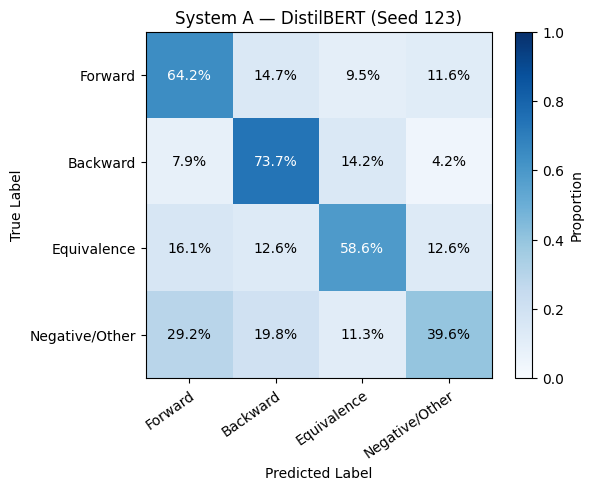

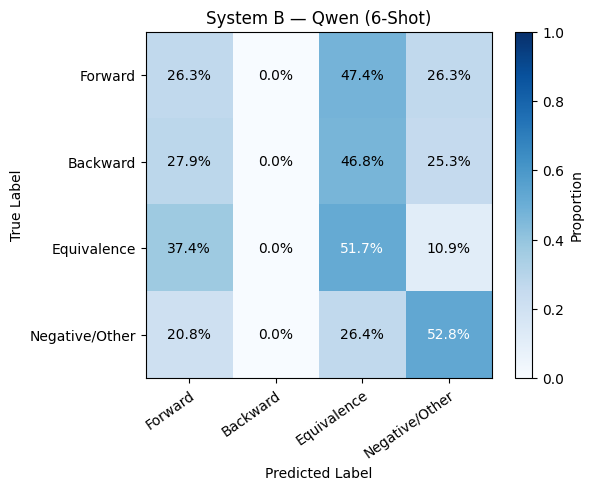

In [65]:
# Label order used in the confusion matrices
labels = [
    "FORWARD_ENTAILMENT",
    "BACKWARD_ENTAILMENT",
    "EQUIVALENCE",
    "NEGATIVE_OTHER"
]

display_labels = [
    "Forward",
    "Backward",
    "Equivalence",
    "Negative/Other"
]

# Calculate normalized confusion matrices
cm_a = confusion_matrix(
    a["label_gold"],
    a["label_pred"],
    labels=labels,
    normalize="true"
)

cm_b = confusion_matrix(
    b["label_gold"],
    b["label_pred"],
    labels=labels,
    normalize="true"
)

# Plot a normalized confusion matrix
def plot_clean_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(6.2, 5))

    # Blue color scheme
    im = ax.imshow(
        cm,
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    ax.set_xticks(np.arange(len(display_labels)))
    ax.set_yticks(np.arange(len(display_labels)))

    ax.set_xticklabels(display_labels)
    ax.set_yticklabels(display_labels)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )

    # Display percentages inside each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                f"{cm[i, j] * 100:.1f}%",
                ha="center",
                va="center",
                color="white" if cm[i, j] > 0.5 else "black"
            )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(title)

    # Color scale
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Proportion")

    fig.tight_layout()
    plt.show()


# System A confusion matrix
plot_clean_matrix(
    cm_a,
    "System A — DistilBERT (Seed 123)"
)

# System B confusion matrix
plot_clean_matrix(
    cm_b,
    "System B — Qwen (6-Shot)"
)

## 4.2 Qualitative Error Analysis

Inspect ten incorrect predictions from System A Seed 123 to identify recurring sources of error.

In [66]:
# Select incorrect predictions from System A Seed 123
system_a_errors = a[
    a["label_gold"] != a["label_pred"]
].head(10)

# Display the 10 error cases
for i, (_, row) in enumerate(system_a_errors.iterrows(), 1):
    print(f"Error #{i}")
    print(f"Instance ID: {row['instance_id']}")
    print(f"Text 1: {row['text1']}")
    print(f"Text 2: {row['text2']}")
    print(f"Gold Label: {row['label_gold']}")
    print(f"Predicted Label: {row['label_pred']}")
    print("-" * 70)

Error #1
Instance ID: dico_phrasis_0000004__en-en__flipped
Text 1: anti-protest laws
Text 2: anti-protest law
Gold Label: FORWARD_ENTAILMENT
Predicted Label: BACKWARD_ENTAILMENT
----------------------------------------------------------------------
Error #2
Instance ID: dico_phrasis_0000010__en-en__flipped
Text 1: Nine children
Text 2: Five children
Gold Label: FORWARD_ENTAILMENT
Predicted Label: BACKWARD_ENTAILMENT
----------------------------------------------------------------------
Error #3
Instance ID: dico_phrasis_0000018__en-en__flipped
Text 1: of all Rage rallies
Text 2: march of anger
Gold Label: FORWARD_ENTAILMENT
Predicted Label: NEGATIVE_OTHER
----------------------------------------------------------------------
Error #4
Instance ID: dico_phrasis_0000018__en-en__original
Text 1: march of anger
Text 2: of all Rage rallies
Gold Label: BACKWARD_ENTAILMENT
Predicted Label: EQUIVALENCE
----------------------------------------------------------------------
Error #5
Instance ID: 

## 4.3 SoftCons Failure Analysis

Inspect five reversed-pair consistency failures from System A Seed 123. A SoftCons failure occurs when the predictions for an original pair and its reversed counterpart do not follow the expected directional label transformation.

In [67]:
# Expected label transformation when a pair is reversed
label_flip_map = {
    "FORWARD_ENTAILMENT": "BACKWARD_ENTAILMENT",
    "BACKWARD_ENTAILMENT": "FORWARD_ENTAILMENT",
    "EQUIVALENCE": "EQUIVALENCE",
    "NEGATIVE_OTHER": "NEGATIVE_OTHER"
}

softcons_failures = []

# Use each original example and locate its reversed counterpart
original_rows = a[
    a["instance_id"].str.endswith("__original")
]

for _, original in original_rows.iterrows():

    reversed_rows = a[
        a["instance_id"] == original["reverse_pair_id"]
    ]

    if len(reversed_rows) != 1:
        continue

    reversed_row = reversed_rows.iloc[0]

    # Expected prediction after reversing the pair
    expected_reversed_prediction = label_flip_map[
        original["label_pred"]
    ]

    # Record cases where directional consistency fails
    if reversed_row["label_pred"] != expected_reversed_prediction:
        softcons_failures.append({
            "instance_id": original["instance_id"],
            "text1": original["text1"],
            "text2": original["text2"],
            "gold_original": original["label_gold"],
            "pred_original": original["label_pred"],
            "gold_reversed": reversed_row["label_gold"],
            "pred_reversed": reversed_row["label_pred"]
        })

# Keep five examples
softcons_failures_df = pd.DataFrame(
    softcons_failures[:5]
)

display(softcons_failures_df)

,instance_id,text1,text2,gold_original,pred_original,gold_reversed,pred_reversed
0,dico_phrasis_0000004__en-en__original,anti-protest law,anti-protest laws,BACKWARD_ENTAILMENT,BACKWARD_ENTAILMENT,FORWARD_ENTAILMENT,BACKWARD_ENTAILMENT
1,dico_phrasis_0000010__en-en__original,Five children,Nine children,BACKWARD_ENTAILMENT,BACKWARD_ENTAILMENT,FORWARD_ENTAILMENT,BACKWARD_ENTAILMENT
2,dico_phrasis_0000018__en-en__original,march of anger,of all Rage rallies,BACKWARD_ENTAILMENT,EQUIVALENCE,FORWARD_ENTAILMENT,NEGATIVE_OTHER
3,dico_phrasis_0000021__en-en__original,One dead,Six killed,BACKWARD_ENTAILMENT,BACKWARD_ENTAILMENT,FORWARD_ENTAILMENT,BACKWARD_ENTAILMENT
4,dico_phrasis_0000031__en-en__original,Brazil,Brazil crowds,BACKWARD_ENTAILMENT,BACKWARD_ENTAILMENT,FORWARD_ENTAILMENT,BACKWARD_ENTAILMENT


In [69]:
# Print the five SoftCons failures in a readable format
for i, row in softcons_failures_df.iterrows():
    print(f"Failure #{i + 1}")
    print(f"Text 1: {row['text1']}")
    print(f"Text 2: {row['text2']}")
    print(
        f"Original: Gold = {row['gold_original']} | "
        f"Predicted = {row['pred_original']}"
    )
    print(
        f"Reversed: Gold = {row['gold_reversed']} | "
        f"Predicted = {row['pred_reversed']}"
    )
    print("-" * 70)

Failure #1
Text 1: anti-protest law
Text 2: anti-protest laws
Original: Gold = BACKWARD_ENTAILMENT | Predicted = BACKWARD_ENTAILMENT
Reversed: Gold = FORWARD_ENTAILMENT | Predicted = BACKWARD_ENTAILMENT
----------------------------------------------------------------------
Failure #2
Text 1: Five children
Text 2: Nine children
Original: Gold = BACKWARD_ENTAILMENT | Predicted = BACKWARD_ENTAILMENT
Reversed: Gold = FORWARD_ENTAILMENT | Predicted = BACKWARD_ENTAILMENT
----------------------------------------------------------------------
Failure #3
Text 1: march of anger
Text 2: of all Rage rallies
Original: Gold = BACKWARD_ENTAILMENT | Predicted = EQUIVALENCE
Reversed: Gold = FORWARD_ENTAILMENT | Predicted = NEGATIVE_OTHER
----------------------------------------------------------------------
Failure #4
Text 1: One dead
Text 2: Six killed
Original: Gold = BACKWARD_ENTAILMENT | Predicted = BACKWARD_ENTAILMENT
Reversed: Gold = FORWARD_ENTAILMENT | Predicted = BACKWARD_ENTAILMENT
----------

## 4.4 Next Step

As a next step, I would test symmetric pair augmentation during training. For every training example `(A, B)`, I would add the reversed pair `(B, A)` with the corresponding reversed label. For example, if `(A, B)` is labeled `FORWARD_ENTAILMENT`, then `(B, A)` would be added as `BACKWARD_ENTAILMENT`.

I expect this to improve consistency because the SoftCons failures showed that DistilBERT often did not adjust its prediction correctly when the input order was reversed. Training explicitly in both directions could help the model learn how entailment labels should change under reversal, potentially improving SoftCons and HardCons.